In [2]:
# ============================================================
# BLOQUE 1 — CARGA UNIVERSAL DEL EXPERIMENTO
# ============================================================

import os
import sys
import glob
import yaml
import joblib

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

# ============================================================
# DETECCIÓN ROBUSTA DEL ROOT DEL PROYECTO
# ============================================================

current = Path.cwd()

while current.name != "eeg_hmm_project":

    if current.parent == current:
        raise RuntimeError(
            "❌ No se encontró la carpeta eeg_hmm_project"
        )

    current = current.parent

project_root = str(current)

print("=" * 60)
print("PROJECT ROOT")
print("=" * 60)
print(project_root)

# ------------------------------------------------------------
# YAML
# ------------------------------------------------------------

YAML_NAME = "feat_task_k4_diag_pca90_hjorthonly_temporalqc.yaml"

yaml_path = os.path.join(
    project_root,
    "configs",
    "experiments",
    "depured_methology_experiments",
    YAML_NAME
)

print("\nYAML:")
print(yaml_path)

with open(yaml_path, 'r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

exp_name = cfg['experiment']['name']

n_states = cfg['pipeline']['hmm']['k_states']

cov_type = cfg['pipeline']['hmm']['covariance_type']

print("\n" + "=" * 60)
print("EXPERIMENT CONFIG")
print("=" * 60)

print(f"Experiment: {exp_name}")
print(f"K States : {n_states}")
print(f"Cov Type : {cov_type}")

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def clean_path(path_str):

    limpio = (
        path_str
        .replace('../../', '')
        .replace('../', '')
    )

    return os.path.normpath(
        os.path.join(project_root, limpio)
    )

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

features_dir = clean_path(
    cfg['paths']['features_dir']
)

output_dir = clean_path(
    cfg['paths']['output_dir']
)

exp_dir = os.path.join(
    output_dir,
    exp_name
)

print("\n" + "=" * 60)
print("PATHS")
print("=" * 60)

print(f"Features Dir:\n{features_dir}")
print(f"\nExperiment Dir:\n{exp_dir}")

# ------------------------------------------------------------
# LOAD FEATURES
# ------------------------------------------------------------

feature_files = sorted(
    glob.glob(
        os.path.join(features_dir, '*_features.npy')
    )
)

print(f"\nFeatures files encontrados: {len(feature_files)}")

X_original = np.vstack([
    np.load(f)
    for f in feature_files
])

print(f"\nX_original shape: {X_original.shape}")

# ------------------------------------------------------------
# LOAD PCA MATRICES
# ------------------------------------------------------------

X_pca = np.load(
    os.path.join(exp_dir, 'X_pca.npy')
)

print(f"X_pca shape: {X_pca.shape}")

# ------------------------------------------------------------
# LOAD VITERBI
# ------------------------------------------------------------

viterbi_paths = np.load(
    os.path.join(
        exp_dir,
        f'viterbi_paths_k{n_states}.npy'
    )
)

print(f"Viterbi shape: {viterbi_paths.shape}")

# ------------------------------------------------------------
# LOAD MODEL
# ------------------------------------------------------------

model = joblib.load(
    os.path.join(
        exp_dir,
        f'hmm_model_k{n_states}.pkl'
    )
)

print("\n✅ Modelo cargado correctamente")

# ------------------------------------------------------------
# LOAD SCALER
# ------------------------------------------------------------

scaler = joblib.load(
    os.path.join(exp_dir, 'scaler.pkl')
)

X_scaled = scaler.transform(X_original)

print(f"\nX_scaled shape: {X_scaled.shape}")

# ------------------------------------------------------------
# SANITY CHECK
# ------------------------------------------------------------

assert len(viterbi_paths) == X_scaled.shape[0]

print("\n✅ Sanity check superado")

PROJECT ROOT
c:\Proyectos\eeg_hmm_project

YAML:
c:\Proyectos\eeg_hmm_project\configs\experiments\depured_methology_experiments\feat_task_k4_diag_pca90_hjorthonly_temporalqc.yaml

EXPERIMENT CONFIG
Experiment: feat_task_k4_diag_pca90_hjorthonly_temporalqc
K States : 4
Cov Type : diag

PATHS
Features Dir:
c:\Proyectos\eeg_hmm_project\data\interim\features\task_hjorthonly_temporalqc

Experiment Dir:
c:\Proyectos\eeg_hmm_project\outputs\processed\experiments\feature_hmm\task\feat_task_k4_diag_pca90_hjorthonly_temporalqc

Features files encontrados: 118

X_original shape: (25949, 38)
X_pca shape: (25949, 22)
Viterbi shape: (25949,)

✅ Modelo cargado correctamente

X_scaled shape: (25949, 38)

✅ Sanity check superado


EVOKED STATE DYNAMICS
Estados HMM: 4
Subjects: 118

Reconstruyendo épocas...

Ventanas detectadas: 11
GO: 1179 épocas
NOGO: 1180 épocas
ADULTO_GO: 599 épocas
ADULTO_NOGO: 600 épocas
ADOLESCENTE_GO: 580 épocas
ADOLESCENTE_NOGO: 580 épocas

TIME AXIS
Inicio real: -400.0 ms
Final real: 600.0 ms


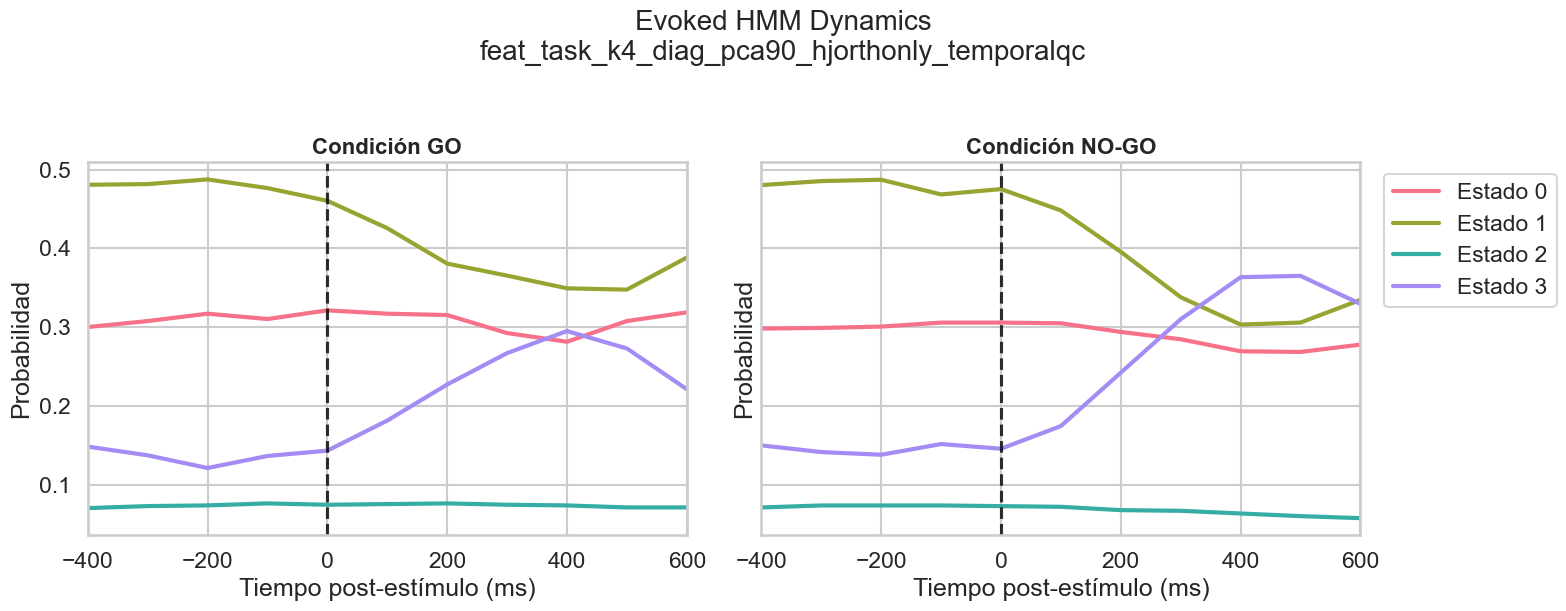

In [6]:
# ============================================================
# BLOQUE 2 — EVOKED STATE DYNAMICS
# ============================================================

from collections import Counter

# ============================================================
# PARÁMETROS TEMPORALES
# ============================================================

EPOCH_START_MS = -500

WINDOW_SIZE_MS = 200
STEP_SIZE_MS = 100

# ============================================================
# LISTA ADULTOS
# ============================================================

LISTA_ADULTOS = [
    'AAELSC', 'AAGFSC', 'EDGSSIN', 'FIJRBSIN', 'GSASC',
    'IJALSC', 'JAGSSC', 'LHACSIN', 'MAEGLSC', 'MAHLSC',
    'MFGSIN', 'MGOKSC', 'RAMPSIN', 'SDBGSIN', 'VMRSIN',
    'AVLLSC', 'BMPSC', 'CGMSIN', 'CJGSIN', 'CPGSC',
    'CPMHSIN', 'GGMSIN', 'IABWSC', 'JAUSIN', 'JGCSC',
    'MGVGSC', 'RKACSC', 'SEOOSIN', 'TTOSC', 'VBPSIN'
]

# ============================================================
# LENGTH FILES
# ============================================================

length_files = sorted(
    glob.glob(
        os.path.join(features_dir, '*_lengths.npy')
    )
)

print("=" * 60)
print("EVOKED STATE DYNAMICS")
print("=" * 60)

print(f"Estados HMM: {n_states}")
print(f"Subjects: {len(length_files)}")

# ============================================================
# HELPERS
# ============================================================

def parse_subject_info(filename):

    clean_name = filename.upper()

    clean_name = (
        clean_name
        .replace('_SIN_CONTEXTO', '')
        .replace('_EPO', '')
        .replace('_LENGTHS.NPY', '')
        .replace('.NPY', '')
    )

    if clean_name.endswith("NOGO"):

        condicion = "NOGO"
        subject_id_real = clean_name[:-4]

    elif clean_name.endswith("NG"):

        condicion = "NOGO"
        subject_id_real = clean_name[:-2]

    elif clean_name.endswith("GO"):

        condicion = "GO"
        subject_id_real = clean_name[:-2]

    else:

        condicion = "GO"
        subject_id_real = clean_name

    grupo = "ADOLESCENTE"

    for adulto in LISTA_ADULTOS:

        if subject_id_real.startswith(adulto):

            grupo = "ADULTO"
            break

    return subject_id_real, grupo, condicion

# ============================================================
# RECONSTRUCCIÓN DE ÉPOCAS
# ============================================================

print("\nReconstruyendo épocas...")

secuencias_crudas = {
    "GO": [],
    "NOGO": [],
    "ADULTO_GO": [],
    "ADULTO_NOGO": [],
    "ADOLESCENTE_GO": [],
    "ADOLESCENTE_NOGO": []
}

start_idx = 0

todas_las_longitudes = []

for f_path in length_files:

    filename = os.path.basename(f_path)

    subject_id_real, grupo, condicion = parse_subject_info(
        filename
    )

    lengths = np.load(f_path)

    for ep_len in lengths:

        ep_path = viterbi_paths[
            start_idx:start_idx + ep_len
        ]

        start_idx += ep_len

        todas_las_longitudes.append(ep_len)

        secuencias_crudas[condicion].append(
            ep_path
        )

        secuencias_crudas[
            f"{grupo}_{condicion}"
        ].append(ep_path)

# ============================================================
# DETECCIÓN AUTOMÁTICA
# ============================================================

WINDOWS_PER_EPOCH = Counter(
    todas_las_longitudes
).most_common(1)[0][0]

print(f"\nVentanas detectadas: {WINDOWS_PER_EPOCH}")

# ============================================================
# FILTRAR ÉPOCAS VÁLIDAS
# ============================================================

matrices = {}

for key, lista_epocas in secuencias_crudas.items():

    epocas_validas = [
        ep for ep in lista_epocas
        if len(ep) == WINDOWS_PER_EPOCH
    ]

    matrices[key] = np.array(epocas_validas)

    print(f"{key}: {len(epocas_validas)} épocas")

# ============================================================
# EJE TEMPORAL
# ============================================================

time_axis = (
    np.arange(WINDOWS_PER_EPOCH)
    * STEP_SIZE_MS
    + EPOCH_START_MS
    + (WINDOW_SIZE_MS / 2)
)

print("\n" + "=" * 60)
print("TIME AXIS")
print("=" * 60)

print(f"Inicio real: {time_axis[0]} ms")
print(f"Final real: {time_axis[-1]} ms")

# ============================================================
# PROBABILIDADES
# ============================================================

def calcular_probabilidades(matriz, n_states):

    if len(matriz) == 0:

        return np.zeros(
            (n_states, WINDOWS_PER_EPOCH)
        )

    probs = np.zeros(
        (n_states, matriz.shape[1])
    )

    for s in range(n_states):

        probs[s] = np.mean(
            matriz == s,
            axis=0
        )

    return probs

probs = {
    key: calcular_probabilidades(value, n_states)
    for key, value in matrices.items()
}

# ============================================================
# PLOT GO vs NOGO
# ============================================================

sns.set_theme(
    style="whitegrid",
    context="talk"
)

colors = sns.color_palette(
    "husl",
    n_states
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
    sharey=True,
    sharex=True
)

paneles = [
    ("GO", "Condición GO"),
    ("NOGO", "Condición NO-GO")
]

for ax, (key, title) in zip(axes, paneles):

    matriz = probs[key]

    for s in range(n_states):

        ax.plot(
            time_axis,
            matriz[s],
            lw=3,
            label=f"Estado {s}",
            color=colors[s]
        )

    ax.set_title(
        title,
        fontsize=16,
        fontweight='bold'
    )

    ax.set_xlabel(
        "Tiempo post-estímulo (ms)"
    )

    ax.set_ylabel(
        "Probabilidad"
    )

    ax.axvline(
        x=0,
        linestyle='--',
        alpha=0.8,
        color='black'
    )

    ax.set_xlim(
        time_axis.min(),
        time_axis.max()
    )

axes[1].legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.suptitle(
    f"Evoked HMM Dynamics\n{exp_name}",
    fontsize=20,
    y=1.03
)

plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# BLOQUE 3 — DISTRIBUCIÓN GLOBAL
# ============================================================

total_windows = len(viterbi_paths)

print("=" * 60)
print(f"GLOBAL STATE DISTRIBUTION (K={n_states})")
print("=" * 60)

print(f"Total windows: {total_windows:,}\n")

for s in range(n_states):

    n = np.sum(viterbi_paths == s)

    occupancy = (n / total_windows) * 100

    print(
        f"State {s}: "
        f"{occupancy:.2f}% "
        f"(n={n:,})"
    )

GLOBAL STATE DISTRIBUTION (K=4)
Total windows: 25,949

State 0: 30.01% (n=7,786)
State 1: 41.68% (n=10,815)
State 2: 7.11% (n=1,845)
State 3: 21.21% (n=5,503)


In [8]:
# ============================================================
# BLOQUE 4 — STATE PROFILES
# ============================================================

state_profiles = np.zeros(
    (n_states, X_scaled.shape[1])
)

for s in range(n_states):

    idx = (viterbi_paths == s)

    state_profiles[s] = np.mean(
        X_scaled[idx],
        axis=0
    )

print("=" * 60)
print("STATE PROFILES")
print("=" * 60)

print(f"Shape: {state_profiles.shape}")

print("\nRango:")

print(f"Min:  {state_profiles.min():.4f}")
print(f"Max:  {state_profiles.max():.4f}")
print(f"Mean: {state_profiles.mean():.4f}")
print(f"STD:  {state_profiles.std():.4f}")

STATE PROFILES
Shape: (4, 38)

Rango:
Min:  -1.6437
Max:  0.7453
Mean: -0.1537
STD:  0.5633


COSINE SIMILARITY MATRIX
[[ 1.     -0.3787 -0.811  -0.2278]
 [-0.3787  1.      0.5108 -0.7457]
 [-0.811   0.5108  1.     -0.216 ]
 [-0.2278 -0.7457 -0.216   1.    ]]


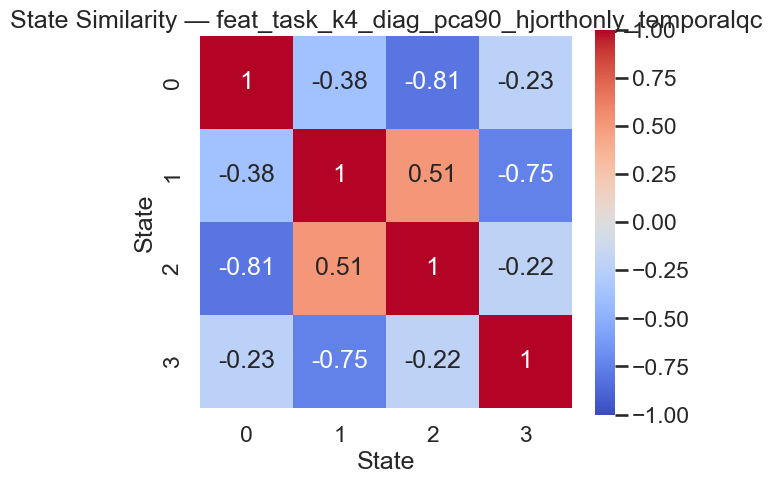

In [9]:
# ============================================================
# BLOQUE 5 — COSINE SIMILARITY
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(
    state_profiles
)

print("=" * 60)
print("COSINE SIMILARITY MATRIX")
print("=" * 60)

print(
    np.round(sim_matrix, 4)
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    sim_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    square=True
)

plt.title(
    f"State Similarity — {exp_name}"
)

plt.xlabel("State")
plt.ylabel("State")

plt.show()

In [9]:
# ============================================================
# BLOQUE 5 — TABLA DE SEPARABILIDAD
# ============================================================

rows = []

for s in range(n_states):

    similarities = sim_matrix[s].copy()

    similarities[s] = -999

    best_match = np.argmax(similarities)

    rows.append({
        'state': s,
        'most_similar_state': best_match,
        'similarity': similarities[best_match]
    })

df_sep = pd.DataFrame(rows)

print(df_sep)

upper_triangle = sim_matrix[
    np.triu_indices(n_states, k=1)
]

print("\nMean inter-state similarity:")
print(np.mean(upper_triangle))

   state  most_similar_state  similarity
0      0                   2   -0.281157
1      1                   0   -0.494915
2      2                   0   -0.281157

Mean inter-state similarity:
-0.49027104374190794


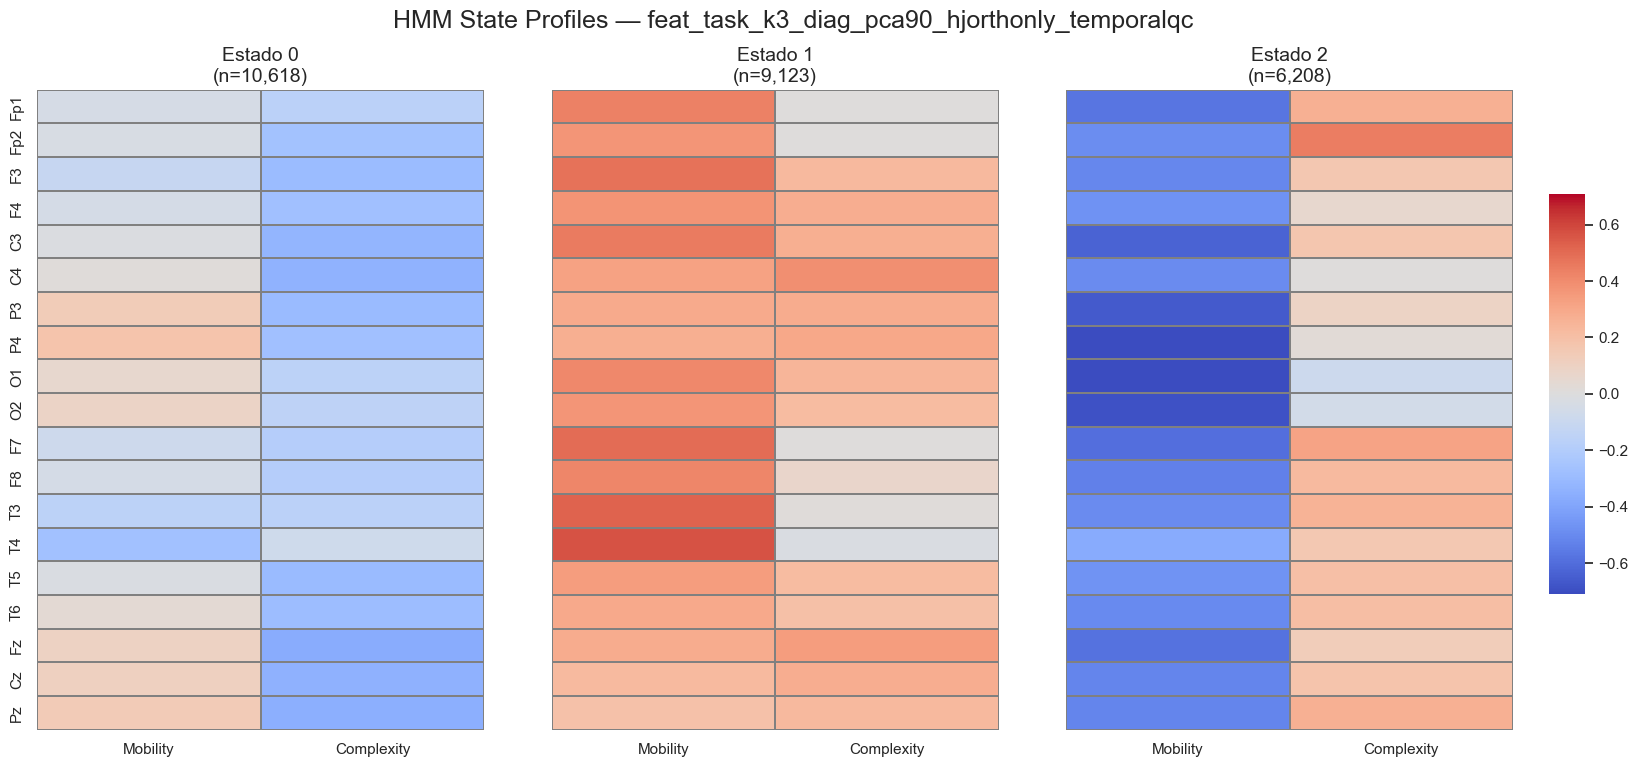

In [10]:
# ============================================================
# BLOQUE 6 — TOPOGRAFÍAS / HEATMAPS
# ============================================================

sns.set_theme(style="white")

# ------------------------------------------------------------
# FEATURES ACTIVAS
# ------------------------------------------------------------

metrics = [
    'Mobility',
    'Complexity'
]

# ------------------------------------------------------------
# CANALES
# ------------------------------------------------------------

ch_names = [
    'Fp1','Fp2','F3','F4','C3','C4','P3','P4',
    'O1','O2','F7','F8','T3','T4','T5','T6',
    'Fz','Cz','Pz'
]

n_channels = len(ch_names)

n_metrics = len(metrics)

# ------------------------------------------------------------
# RESHAPE
# ------------------------------------------------------------

state_profiles_3d = np.zeros(
    (n_states, n_channels, n_metrics)
)

for m_idx in range(n_metrics):

    start_col = m_idx * n_channels

    end_col = (m_idx + 1) * n_channels

    state_profiles_3d[:, :, m_idx] = (
        state_profiles[:, start_col:end_col]
    )

# ------------------------------------------------------------
# VISUALIZACIÓN
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    n_states,
    figsize=(6 * n_states, 8),
    sharey=True
)

if n_states == 1:
    axes = [axes]

global_absmax = np.max(
    np.abs(state_profiles_3d)
)

cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])

for s in range(n_states):

    ax = axes[s]

    sns.heatmap(
        state_profiles_3d[s],
        cmap='coolwarm',
        center=0,
        vmin=-global_absmax,
        vmax=global_absmax,
        xticklabels=metrics,
        yticklabels=ch_names,
        linewidths=0.3,
        linecolor='gray',
        ax=ax,
        cbar=(s == 0),
        cbar_ax=None if s > 0 else cbar_ax
    )

    n_windows = np.sum(viterbi_paths == s)

    ax.set_title(
        f"Estado {s}\n(n={n_windows:,})",
        fontsize=14
    )

plt.suptitle(
    f"HMM State Profiles — {exp_name}",
    fontsize=18,
    y=0.98
)

plt.subplots_adjust(
    left=0.08,
    right=0.9,
    top=0.88,
    bottom=0.08,
    wspace=0.15
)

plt.show()

In [11]:
# ============================================================
# BLOQUE 7 — DWELL TIME
# ============================================================

WINDOW_STEP_MS = 100

def get_mean_dwell_time(path, state, step_ms):

    is_s = (path == state)

    if not np.any(is_s):
        return 0.0

    diffs = np.diff(
        np.concatenate(([0], is_s.view(np.int8), [0]))
    )

    starts = np.where(diffs == 1)[0]

    ends = np.where(diffs == -1)[0]

    return np.mean(
        ends - starts
    ) * step_ms

print("=" * 60)
print("DWELL TIMES")
print("=" * 60)

for s in range(n_states):

    dwell = get_mean_dwell_time(
        viterbi_paths,
        s,
        WINDOW_STEP_MS
    )

    print(
        f"State {s}: "
        f"{dwell:.2f} ms"
    )

DWELL TIMES
State 0: 883.36 ms
State 1: 1070.77 ms
State 2: 578.56 ms


In [12]:
# ============================================================
# CARGAR EL HMM CORRECTO + MATRIZ DE TRANSICIÓN
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# CARGAR MODELO HMM
# ------------------------------------------------------------

model_path = os.path.join(
    exp_dir,
    f'hmm_model_k{n_states}.pkl'
)

print(f"Cargando modelo desde:\n{model_path}")

model = joblib.load(model_path)

# ------------------------------------------------------------
# MATRIZ DE TRANSICIÓN
# ------------------------------------------------------------

transmat = model.transmat_

print("\n" + "=" * 60)
print("TRANSITION MATRIX")
print("=" * 60)

df_transmat = pd.DataFrame(
    np.round(transmat, 3),
    index=[f"From S{i}" for i in range(n_states)],
    columns=[f"To S{i}" for i in range(n_states)]
)

print(df_transmat)

# ------------------------------------------------------------
# MÉTRICAS DE PERSISTENCIA
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("STATE PERSISTENCE")
print("=" * 60)

for s in range(n_states):

    occupancy = np.mean(viterbi_paths == s)

    n_windows = np.sum(viterbi_paths == s)

    self_transition = transmat[s, s]

    print(
        f"""
State {s}
---------
Fractional Occupancy : {occupancy:.4f} ({occupancy*100:.2f}%)
Total Windows        : {n_windows:,}
Self-transition      : {self_transition:.4f}
"""
    )

# ------------------------------------------------------------
# ESTADO MÁS PERSISTENTE
# ------------------------------------------------------------

diag_probs = np.diag(transmat)

most_persistent = np.argmax(diag_probs)

print("=" * 60)
print(f"Most persistent state: State {most_persistent}")
print(f"Self-transition: {diag_probs[most_persistent]:.4f}")
print("=" * 60)

Cargando modelo desde:
../../outputs/processed/experiments/feature_hmm/task/feat_task_k3_diag_pca90_hjorthonly_temporalqc\hmm_model_k3.pkl

TRANSITION MATRIX
         To S0  To S1  To S2
From S0  0.881  0.053  0.066
From S1  0.032  0.920  0.048
From S2  0.094  0.052  0.855

STATE PERSISTENCE

State 0
---------
Fractional Occupancy : 0.4092 (40.92%)
Total Windows        : 10,618
Self-transition      : 0.8812


State 1
---------
Fractional Occupancy : 0.3516 (35.16%)
Total Windows        : 9,123
Self-transition      : 0.9199


State 2
---------
Fractional Occupancy : 0.2392 (23.92%)
Total Windows        : 6,208
Self-transition      : 0.8546

Most persistent state: State 1
Self-transition: 0.9199


In [10]:
length_files = sorted(
    glob.glob(
        os.path.join(features_dir, '*_lengths.npy')
    )
)

all_lengths = []

for f in length_files:

    lengths = np.load(f)

    all_lengths.extend(lengths)

print(np.unique(all_lengths))

[11]
